<a href="https://colab.research.google.com/github/fcoliveira-utfpr/relacoes_fisicas_ambiente/blob/main/codigos_python/aula_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 01 · Mapas climatológicos do Paraná com Google Earth Engine

Este notebook gera três mapas para o Paraná a partir de dados abertos do Earth Engine:

1. Precipitação média anual (CHIRPS)
2. Temperatura média anual do ar (ERA5-Land)
3. Deficiência hídrica média anual (TerraClimate)

O período de análise é ajustável na seção **Definições iniciais**. Basta alterar `ANO_INICIO` e `ANO_FIM` e executar todas as células novamente.

# 1. Bibliotecas e autenticação
___

In [1]:
# No Colab, a earthengine-api já vem instalada; a linha abaixo apenas garante
# que a versão esteja atualizada (pode ser removida se preferir)
#!pip install -q --upgrade earthengine-api

import os
import io
import requests
import ee
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from PIL import Image

# ID do projeto do Google Cloud registrado no Earth Engine
ID_PROJETO = 'fcoliveira'

# Abre a janela de login do Google (só é necessário na primeira execução da sessão)
ee.Authenticate()

# Conecta a sessão ao projeto
ee.Initialize(project=ID_PROJETO)
print('Earth Engine conectado ao projeto:', ID_PROJETO)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine conectado ao projeto: fcoliveira


# 2. Definições iniciais
___

Altere aqui o período de análise. Os dois anos são **inclusivos**: `ANO_INICIO = 1991` e `ANO_FIM = 2020` correspondem às normais climatológicas 1991–2020 (30 anos).

| Fonte | Disponível a partir de |
|---|---|
| CHIRPS | 1981 |
| ERA5-Land | 1950 |
| TerraClimate | 1958 |

O fim da série depende da atualização de cada base. Se o período escolhido não estiver totalmente disponível, o notebook avisa antes de gerar o mapa.

In [2]:
# ================== PERÍODO DE ANÁLISE (AJUSTÁVEL) ==================
ANO_INICIO = 2020   # primeiro ano do período (inclusivo)
ANO_FIM    = 2020   # último ano do período (inclusivo)
# ====================================================================

# Validação simples do período informado
assert ANO_FIM >= ANO_INICIO, 'ANO_FIM deve ser maior ou igual a ANO_INICIO.'

# Datas no formato exigido pelo Earth Engine.
# Atenção: em filterDate a data final é EXCLUSIVA, por isso usamos 1º de janeiro
# do ano seguinte ao ANO_FIM (assim o ano final entra completo)
INI = f'{ANO_INICIO}-01-01'
FIM = f'{ANO_FIM + 1}-01-01'

# Número de anos do período, usado para converter totais em médias anuais
N_ANOS = ANO_FIM - ANO_INICIO + 1

# Texto do período para títulos e nomes de arquivo
PERIODO = f'{ANO_INICIO}–{ANO_FIM}' if N_ANOS > 1 else f'{ANO_INICIO}'
SUFIXO  = f'{ANO_INICIO}_{ANO_FIM}'

print(f'Período: {PERIODO} ({N_ANOS} ano(s))  |  filterDate({INI!r}, {FIM!r})')

# ---------- Outras opções ----------
METODO = 'bicubic'          # suavização visual: 'bilinear' ou 'bicubic'
ESCALA_AUTOMATICA = False   # True: limites de cor pelos percentis 2–98% dos dados
PASTA_FIGURAS = 'figuras'   # pasta onde os PNGs serão salvos
os.makedirs(PASTA_FIGURAS, exist_ok=True)

# Ponto de referência destacado nos mapas (longitude, latitude)
SANTA_HELENA = (-54.33, -24.86)

Período: 2020 (1 ano(s))  |  filterDate('2020-01-01', '2021-01-01')


# 3. Área de estudo e funções auxiliares
___

In [3]:
# ---------- Área de estudo: limite do Paraná (FAO GAUL, nível 1 = estados) ----------
parana = (ee.FeatureCollection('FAO/GAUL/2015/level1')
          .filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
          .filter(ee.Filter.eq('ADM1_NAME', 'Parana')))
geom = parana.geometry()

# Retângulo envolvente, usado como região da imagem e como extensão do gráfico.
# Calculado uma única vez para evitar chamadas repetidas ao servidor
coords = geom.bounds().getInfo()['coordinates'][0]
lons = [p[0] for p in coords]
lats = [p[1] for p in coords]
EXTENT = [min(lons), max(lons), min(lats), max(lats)]


def suavizar(img):
    """Troca o vizinho mais próximo por interpolação bilinear/bicúbica.

    Precisa ser aplicada a cada imagem da coleção (com .map) ANTES da redução
    (.sum, .mean), pois o composto resultante perde a projeção original.
    O efeito é apenas visual: a resolução real dos dados não muda.
    """
    return img.resample(METODO)


def verificar_periodo(colecao, nome):
    """Confere se a coleção filtrada cobre todo o período escolhido.

    Interrompe a execução com uma mensagem clara caso o período esteja
    fora da disponibilidade da base de dados.
    """
    n = colecao.size().getInfo()
    if n == 0:
        raise ValueError(f'{nome}: nenhuma imagem encontrada para {PERIODO}.')

    t0 = ee.Date(colecao.aggregate_min('system:time_start')).get('year').getInfo()
    t1 = ee.Date(colecao.aggregate_max('system:time_start')).get('year').getInfo()
    if t0 > ANO_INICIO or t1 < ANO_FIM:
        raise ValueError(
            f'{nome}: dados disponíveis apenas de {t0} a {t1} dentro do filtro. '
            f'Ajuste ANO_INICIO/ANO_FIM para um período coberto pela base.')

    print(f'{nome}: {n} imagens entre {t0} e {t1} ✔')


def limites_automaticos(img, p_min=2, p_max=98):
    """Calcula limites de cor pelos percentis da imagem dentro do Paraná."""
    stats = img.reduceRegion(
        reducer=ee.Reducer.percentile([p_min, p_max]),
        geometry=geom, scale=5000, bestEffort=True, maxPixels=1e9
    ).getInfo()
    vmin = [v for k, v in stats.items() if k.endswith(f'_p{p_min}')][0]
    vmax = [v for k, v in stats.items() if k.endswith(f'_p{p_max}')][0]
    return round(vmin, 1), round(vmax, 1)


def mapa_png(img, vmin, vmax, paleta, titulo, unidade, arquivo):
    """Gera o mapa com legenda e salva em PNG.

    img     : ee.Image com uma única banda
    vmin    : valor mínimo da escala de cores (ignorado se ESCALA_AUTOMATICA=True)
    vmax    : valor máximo da escala de cores (idem)
    paleta  : lista de cores em hexadecimal, sem '#'
    titulo  : título do mapa
    unidade : rótulo da barra de cores
    arquivo : nome do arquivo PNG (salvo em PASTA_FIGURAS)
    """
    if ESCALA_AUTOMATICA:
        vmin, vmax = limites_automaticos(img)
        print(f'Limites automáticos da escala: {vmin} a {vmax}')

    # 1) O Earth Engine renderiza a imagem já colorida e devolve um link para o PNG
    url = img.clip(geom).getThumbURL({
        'min': vmin, 'max': vmax, 'palette': paleta,
        'region': geom.bounds(), 'dimensions': 2000,
        'crs': 'EPSG:4326', 'format': 'png'
    })
    resposta = requests.get(url)
    if resposta.status_code != 200:
        raise RuntimeError(f'Falha ao gerar a imagem: {resposta.text[:300]}')
    png = Image.open(io.BytesIO(resposta.content))

    # 2) O matplotlib monta o mapa final com eixos, título e barra de cores
    cmap = LinearSegmentedColormap.from_list('paleta', ['#' + c for c in paleta])
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.imshow(png, extent=EXTENT, interpolation='bilinear')

    # Ponto de referência
    ax.plot(*SANTA_HELENA, marker='^', color='black', markersize=9)
    ax.annotate('Santa Helena', SANTA_HELENA, xytext=(5, 5),
                textcoords='offset points', fontsize=10)

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')

    # A barra de cores é construída com a mesma paleta e os mesmos limites do GEE
    cb = fig.colorbar(ScalarMappable(norm=Normalize(vmin, vmax), cmap=cmap),
                      ax=ax, shrink=0.8)
    cb.set_label(unidade)

    plt.tight_layout()
    caminho = os.path.join(PASTA_FIGURAS, arquivo)
    plt.savefig(caminho, dpi=200, bbox_inches='tight')
    plt.show()
    print('Figura salva em:', caminho)

/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


# 4. Precipitação média anual (CHIRPS)
___

O CHIRPS combina estimativas de satélite com dados de estações. Aqui usamos a versão em **pêntadas** (totais de 5 dias), que é mais leve que a diária e gera o mesmo total anual.

**Cálculo:** soma de todas as pêntadas do período ÷ número de anos = precipitação média anual (mm/ano).

CHIRPS: 72 imagens entre 2020 e 2020 ✔


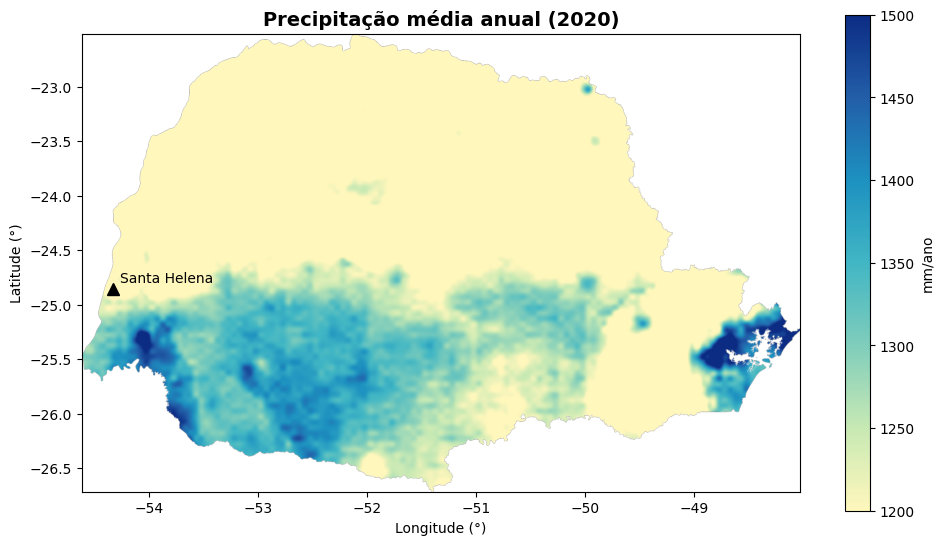

Figura salva em: figuras/aula01_precipitacao_2020_2020.png


In [8]:
col_prec = (ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD')
            .filterDate(INI, FIM)          # recorte temporal
            .select('precipitation'))      # banda de precipitação (mm)
verificar_periodo(col_prec, 'CHIRPS')

prec = (col_prec
        .map(suavizar)       # suavização aplicada imagem a imagem
        .sum()               # total acumulado no período (mm)
        .divide(N_ANOS))     # média anual (mm/ano)

mapa_png(prec, 1200, 1500,
         ['fff7bc', 'c7e9b4', '7fcdbb', '41b6c4', '1d91c0', '225ea8', '0c2c84'],
         f'Precipitação média anual ({PERIODO})', 'mm/ano',
         f'aula01_precipitacao_{SUFIXO}.png')

# 5. Temperatura média anual do ar (ERA5-Land)
___

O ERA5-Land é uma reanálise do ECMWF: combina modelo atmosférico e observações para reconstruir o clima de forma contínua no tempo e no espaço. A temperatura do ar a 2 m vem em **kelvin**.

**Cálculo:** média de todas as temperaturas mensais do período − 273,15 = temperatura média anual (°C).

ERA5-Land: 12 imagens entre 2020 e 2020 ✔


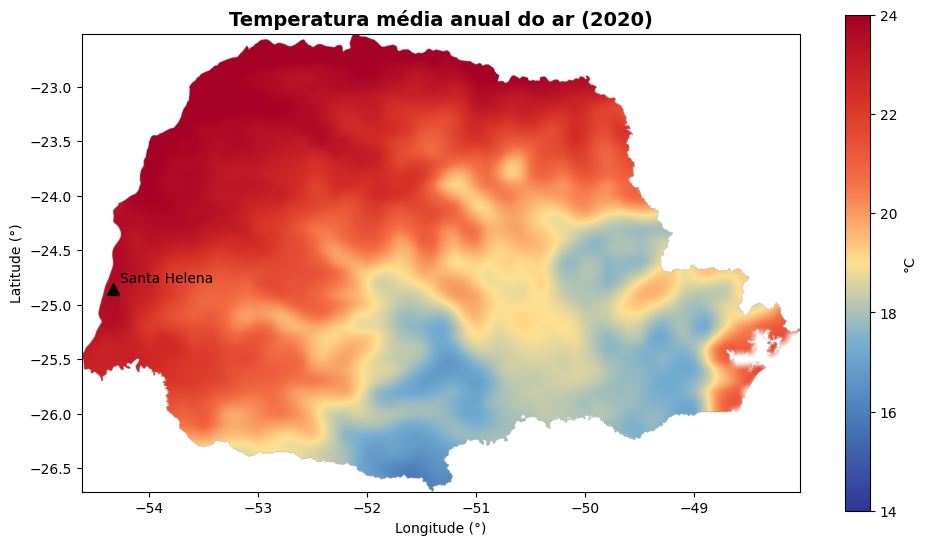

Figura salva em: figuras/aula01_temperatura_2020_2020.png


In [5]:
col_temp = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
            .filterDate(INI, FIM)
            .select('temperature_2m'))     # temperatura do ar a 2 m (K)
verificar_periodo(col_temp, 'ERA5-Land')

temp = (col_temp
        .map(suavizar)
        .mean()              # média de todos os meses do período (K)
        .subtract(273.15))   # conversão de kelvin para °C

mapa_png(temp, 14, 24,
         ['313695', '4575b4', '74add1', 'fee090', 'f46d43', 'd73027', 'a50026'],
         f'Temperatura média anual do ar ({PERIODO})', '°C',
         f'aula01_temperatura_{SUFIXO}.png')

# 6. Deficiência hídrica média anual (TerraClimate)
___

O TerraClimate fornece um balanço hídrico climatológico mensal. A banda `def` é a **deficiência hídrica** (diferença entre a evapotranspiração potencial e a real), em décimos de milímetro.

**Cálculo:** soma das deficiências mensais × 0,1 (fator de escala) ÷ número de anos = deficiência média anual (mm/ano).

TerraClimate: 12 imagens entre 2020 e 2020 ✔


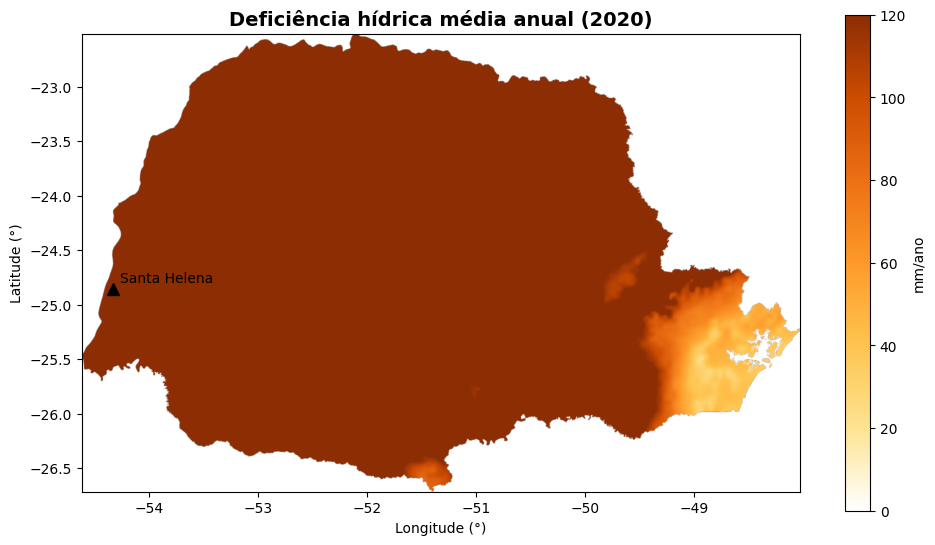

Figura salva em: figuras/aula01_deficit_2020_2020.png


In [9]:
col_def = (ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE')
           .filterDate(INI, FIM)
           .select('def'))                 # deficiência hídrica (0,1 mm)
verificar_periodo(col_def, 'TerraClimate')

defic = (col_def
         .map(suavizar)
         .sum()              # total acumulado no período
         .multiply(0.1)      # fator de escala da banda → mm
         .divide(N_ANOS))    # média anual (mm/ano)

mapa_png(defic, 0, 120,
         ['ffffff', 'fee391', 'fec44f', 'fe9929', 'ec7014', 'cc4c02', '8c2d04'],
         f'Deficiência hídrica média anual ({PERIODO})', 'mm/ano',
         f'aula01_deficit_{SUFIXO}.png')